# MLP Experimentation – Depth, Width, and Activations on MNIST

**Goal:** Understand how architectural choices (number of layers, neurons, activation functions) affect a neural network’s performance, training dynamics, and tendency to overfit.

## What You Will Do

1. Load the MNIST dataset (handwritten digits).
2. Build a baseline MLP with one hidden layer (64 neurons, ReLU).
3. **Experiment 1: Increase depth** – add more hidden layers (2, 3, 4 layers) and observe training/validation accuracy.
4. **Experiment 2: Increase width** – change the number of neurons per layer (128, 256) and compare training time and performance.
5. **Experiment 3: Activation functions** – replace ReLU with Sigmoid and observe the convergence speed.
6. For each experiment, **print loss per epoch** and plot training vs validation curves.
7. Answer the questions at the end.

---

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess: flatten and normalize to [0,1]
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (60000, 784)
Test data shape: (10000, 784)


In [6]:
def build_mlp(layer_units, activation='relu', dropout_rate=0.0, input_dim=784):
    """
    Build a Sequential MLP model.
    :param layer_units: list of ints, number of neurons per hidden layer.
                        e.g., [64] for one hidden layer, [128, 64] for two.
    :param activation: activation function for hidden layers ('relu', 'sigmoid', 'tanh').
    :param dropout_rate: dropout probability (0.0 means no dropout).
    :return: compiled model
    """
    model = Sequential()
    # Input layer + first hidden layer
    model.add(Dense(layer_units[0], activation=activation, input_dim=input_dim))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    
    # Additional hidden layers
    for units in layer_units[1:]:
        model.add(Dense(units, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    
    # Output layer (softmax for 10 classes)
    model.add(Dense(10, activation='softmax'))
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [9]:
configs_depth = {
    '1 layer (64)': [64],
    '2 layers (64,64)': [64, 64],
    '3 layers (64,64,64)': [64, 64, 64],
    '4 layers (64,64,64,64)': [64, 64, 64, 64],
}

histories_depth = {}
batch_size = 128
epochs = 10

for name, layer_units in configs_depth.items():
    print(f"Training {name}...")
    model = build_mlp(layer_units, activation='relu')
    history = model.fit(X_train, y_train_cat,
                        validation_split=0.2,
                        epochs=epochs,
                        batch_size=batch_size,
                        verbose=1)
    histories_depth[name] = history

Training 1 layer (64)...


C:\Users\engal\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8745 - loss: 0.4651 - val_accuracy: 0.9318 - val_loss: 0.2440
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9371 - loss: 0.2201 - val_accuracy: 0.9490 - val_loss: 0.1848
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9514 - loss: 0.1699 - val_accuracy: 0.9561 - val_loss: 0.1567
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9607 - loss: 0.1382 - val_accuracy: 0.9609 - val_loss: 0.1399
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9664 - loss: 0.1179 - val_accuracy: 0.9628 - val_loss: 0.1299
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9719 - loss: 0.1007 - val_accuracy: 0.9673 - val_loss: 0.1191
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9740 - loss: 0.0888 - val_accuracy: 0.9692 - val_loss: 0.1131
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9775 - loss: 0.0791 - val_accuracy: 0.

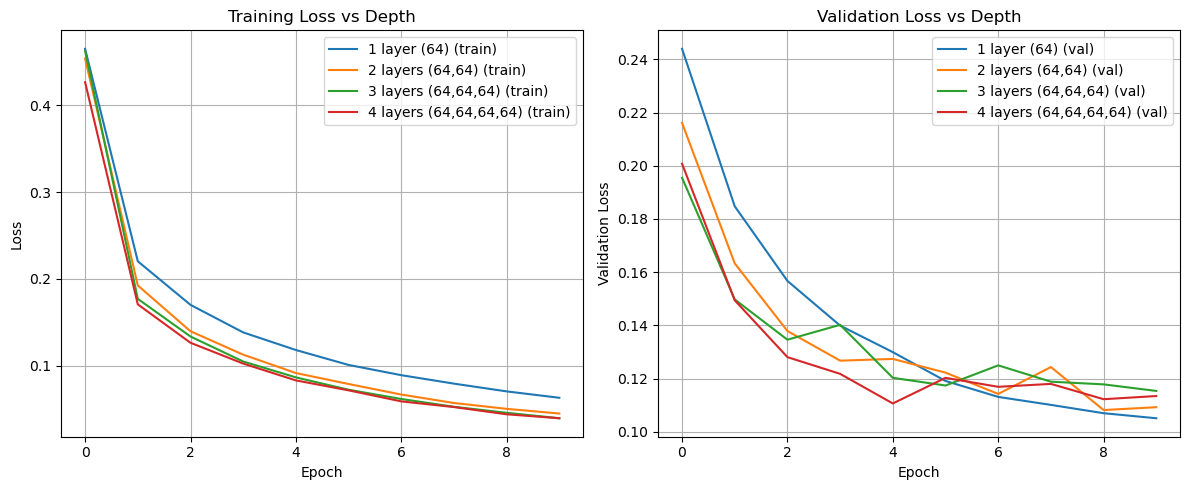

In [11]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for name, hist in histories_depth.items():
    plt.plot(hist.history['loss'], label=f'{name} (train)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Depth')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
for name, hist in histories_depth.items():
    plt.plot(hist.history['val_loss'], label=f'{name} (val)')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss vs Depth')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
configs_width = {
    'narrow (32,32)': [32, 32],
    'baseline (64,64)': [64, 64],
    'wide (128,128)': [128, 128],
    'very wide (256,256)': [256, 256],
}
histories_width = {}

for name, layer_units in configs_width.items():
    print(f"Training {name}...")
    model = build_mlp(layer_units, activation='relu')
    history = model.fit(X_train, y_train_cat,
                        validation_split=0.2,
                        epochs=epochs,
                        batch_size=batch_size,
                        verbose=1)
    histories_width[name] = history

Training narrow (32,32)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8407 - loss: 0.5635 - val_accuracy: 0.9255 - val_loss: 0.2627
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9305 - loss: 0.2376 - val_accuracy: 0.9416 - val_loss: 0.2042
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9438 - loss: 0.1919 - val_accuracy: 0.9493 - val_loss: 0.1746
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9520 - loss: 0.1645 - val_accuracy: 0.9533 - val_loss: 0.1626
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9572 - loss: 0.1444 - val_accuracy: 0.9567 - val_loss: 0.1522
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9626 - loss: 0.1299 - val_accuracy: 0.9585 - val_loss: 0.1480
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9651 - loss: 0.1183 - val_accuracy: 0.9584 - val_loss: 0.1420
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9672 - loss

In [15]:
activations = ['relu', 'sigmoid']
histories_act = {}
base_config = [64, 64, 64]   # 3 hidden layers, 64 neurons each

for act in activations:
    print(f"Training with activation: {act}...")
    model = build_mlp(base_config, activation=act)
    history = model.fit(X_train, y_train_cat,
                        validation_split=0.2,
                        epochs=epochs,
                        batch_size=batch_size,
                        verbose=1)
    histories_act[act] = history

Training with activation: relu...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8760 - loss: 0.4267 - val_accuracy: 0.9429 - val_loss: 0.1932
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9487 - loss: 0.1741 - val_accuracy: 0.9539 - val_loss: 0.1587
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9609 - loss: 0.1303 - val_accuracy: 0.9624 - val_loss: 0.1250
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9698 - loss: 0.1014 - val_accuracy: 0.9632 - val_loss: 0.1191
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9746 - loss: 0.0846 - val_accuracy: 0.9681 - val_loss: 0.1132
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9793 - loss: 0.0679 - val_accuracy: 0.9693 - val_loss: 0.1072
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9815 - loss: 0.0600 - val_accuracy: 0.9685 - val_loss: 0.1106
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9838

In [17]:
print("="*60)
print("Depth Experiment – Test Accuracy")
print("-"*60)
for name, hist in histories_depth.items():
    # Evaluate on test set
    model = build_mlp(configs_depth[name], activation='relu')
    model.fit(X_train, y_train_cat, epochs=epochs, batch_size=batch_size, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"{name:20} -> Test accuracy: {test_acc:.4f}")

print("\n" + "="*60)
print("Width Experiment – Test Accuracy")
print("-"*60)
for name, hist in histories_width.items():
    model = build_mlp(configs_width[name], activation='relu')
    model.fit(X_train, y_train_cat, epochs=epochs, batch_size=batch_size, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"{name:20} -> Test accuracy: {test_acc:.4f}")

print("\n" + "="*60)
print("Activation Experiment – Test Accuracy")
print("-"*60)
for act, hist in histories_act.items():
    model = build_mlp([64,64,64], activation=act)
    model.fit(X_train, y_train_cat, epochs=epochs, batch_size=batch_size, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Activation {act:7} -> Test accuracy: {test_acc:.4f}")

Depth Experiment – Test Accuracy
------------------------------------------------------------
1 layer (64)         -> Test accuracy: 0.9731
2 layers (64,64)     -> Test accuracy: 0.9724
3 layers (64,64,64)  -> Test accuracy: 0.9701
4 layers (64,64,64,64) -> Test accuracy: 0.9737

Width Experiment – Test Accuracy
------------------------------------------------------------
narrow (32,32)       -> Test accuracy: 0.9656
baseline (64,64)     -> Test accuracy: 0.9734
wide (128,128)       -> Test accuracy: 0.9754
very wide (256,256)  -> Test accuracy: 0.9769

Activation Experiment – Test Accuracy
------------------------------------------------------------
Activation relu    -> Test accuracy: 0.9762
Activation sigmoid -> Test accuracy: 0.9681


## Questions to Answer

Write your answers below (double-click to edit).

1. **How does increasing the number of hidden layers (depth) affect training and validation accuracy?** What happens when you add too many layers?

2. **How does increasing the number of neurons per layer (width) affect performance and training speed?** Is wider always better?

3. **What difference do you observe between ReLU and Sigmoid activations?** Which converges faster and why?

4. **Why is it important to plot training loss and validation loss over epochs?** What does a large gap between them indicate?

5. **How does the MLP overcome the XOR limitation that the single perceptron had?** (Relate back to the previous lecture.)